<a href="https://colab.research.google.com/github/Subhranshu-123/BIKE2/blob/main/R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# View the first few rows
install.packages("zoo")
library(zoo)
head(AirPassengers)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric




,Jan,Feb,Mar,Apr,May,Jun
1949,112,118,132,129,121,135


LOAD AIR PASSENGER DATASET

PLOT WITH YEAR VS PASSENGERS

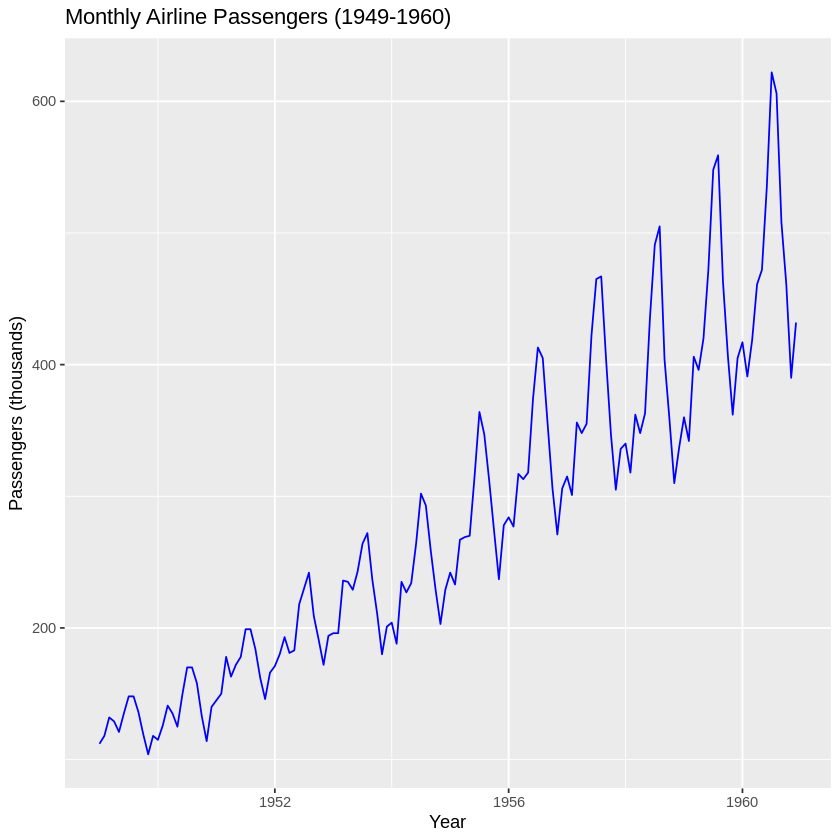

In [2]:
library(ggplot2)

# Convert time series to a data frame
air_data <- data.frame(
  Year = as.numeric(time(AirPassengers)),
  Passengers = as.numeric(AirPassengers)
)

# Basic plot
ggplot(air_data, aes(x = Year, y = Passengers)) +
  geom_line(color = "blue") +
  labs(title = "Monthly Airline Passengers (1949-1960)", y = "Passengers (thousands)")


DECOMPOSITION MULTIPLICATIVE

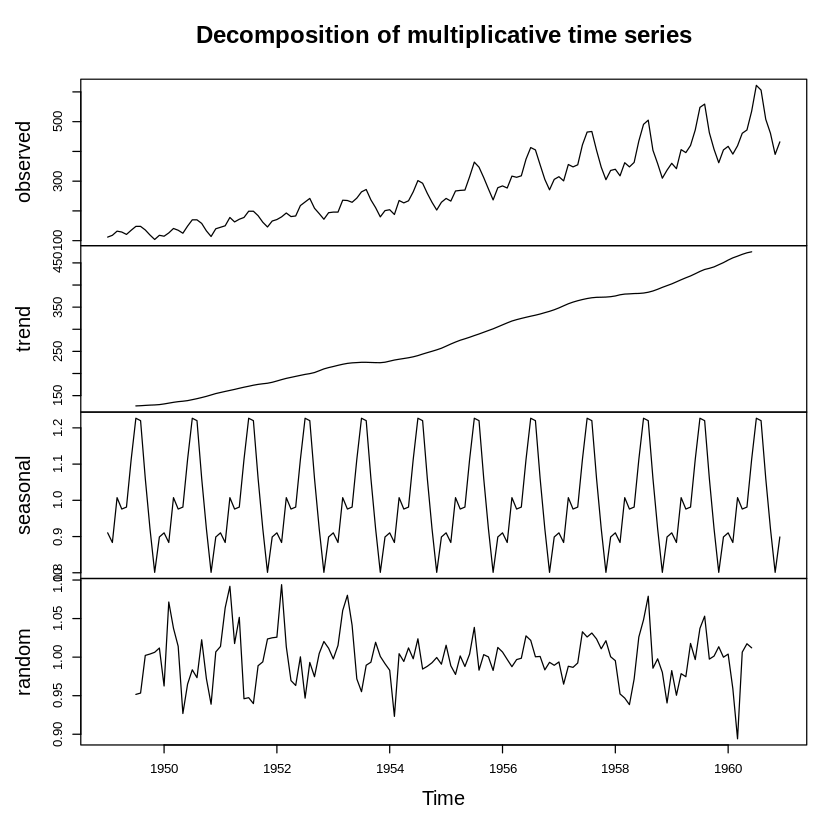

In [3]:
# Perform multiplicative decomposition
decomposed_air <- decompose(AirPassengers, type = "multiplicative")

# Plot the components (Observed, Trend, Seasonal, and Random)
plot(decomposed_air)


INSTALL PACKAGE GGFORTIFY

In [4]:
# Install and load the necessary package
install.packages("ggfortify")
library(ggfortify)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘gridExtra’




DO AUTOPLOT

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the ggfortify package.
  Please report the issue at <https://github.com/sinhrks/ggfortify/issues>.”
Warning message:
“Removed 24 rows containing missing values or values outside the scale range
(`geom_line()`).”


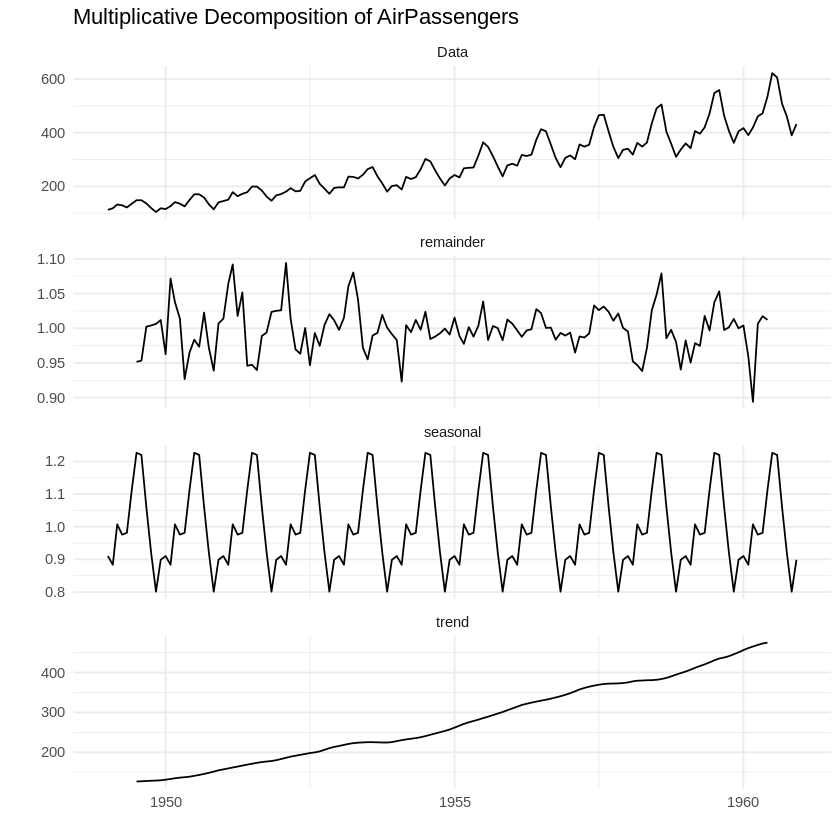

In [7]:
# Decompose and plot with ggplot styling
decomposed_air <- decompose(AirPassengers, type = "multiplicative")
autoplot(decomposed_air) +
  theme_minimal() +
  labs(title = "Multiplicative Decomposition of AirPassengers")

ACF VS PACF

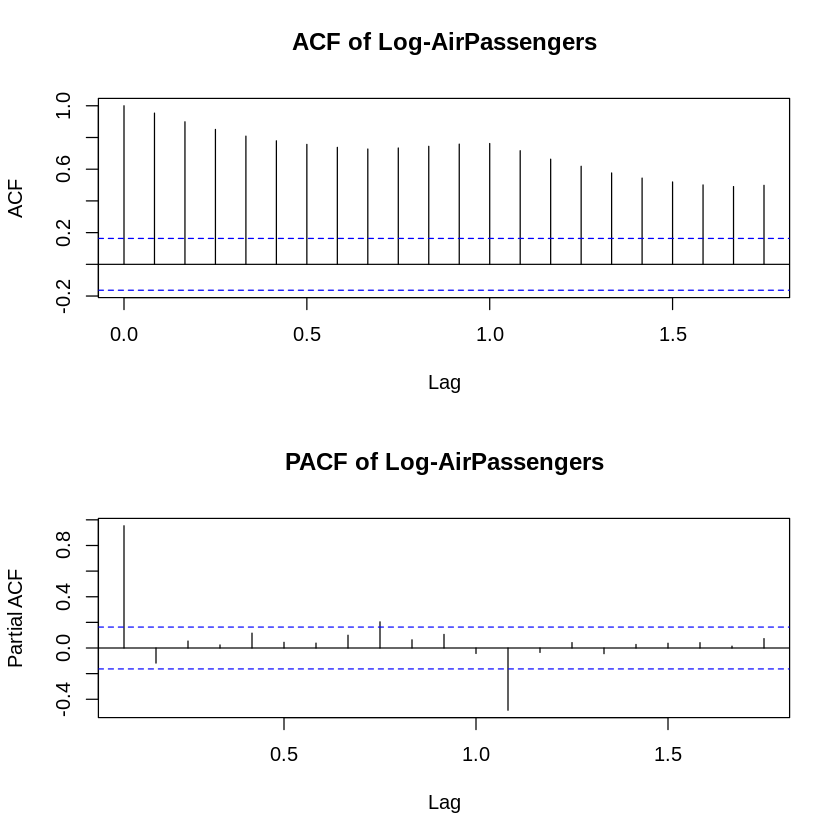

In [8]:
# Split the plot window into 2 rows and 1 column
par(mfrow = c(2, 1))

# ACF: Autocorrelation Function (shows correlation with lags)
acf(log(AirPassengers), main = "ACF of Log-AirPassengers")

# PACF: Partial Autocorrelation Function (shows direct correlation after removing intermediate lags)
pacf(log(AirPassengers), main = "PACF of Log-AirPassengers")


FORECAST TO SEE PATTERN OF ACF AND PACF

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘RcppArmadillo’


Registered S3 methods overwritten by 'forecast':
  method                 from     
  autoplot.Arima         ggfortify
  autoplot.acf           ggfortify
  autoplot.ar            ggfortify
  autoplot.bats          ggfortify
  autoplot.decomposed.ts ggfortify
  autoplot.ets           ggfortify
  autoplot.forecast      ggfortify
  autoplot.stl           ggfortify
  autoplot.ts            ggfortify
  fitted.ar              ggfortify
  fortify.ts             ggfortify
  residuals.ar           ggfortify



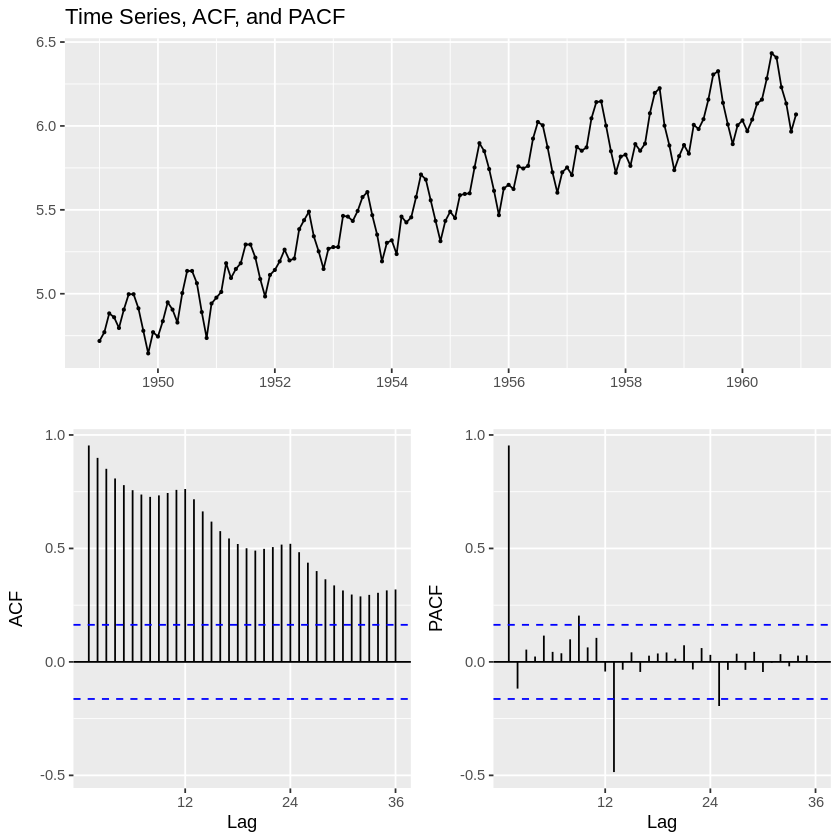

In [10]:
install.packages("forecast")
library(forecast)

# This single command generates all three plots
ggtsdisplay(log(AirPassengers), main = "Time Series, ACF, and PACF")


CHECK STATIONARITY VS NON STATIONARITY

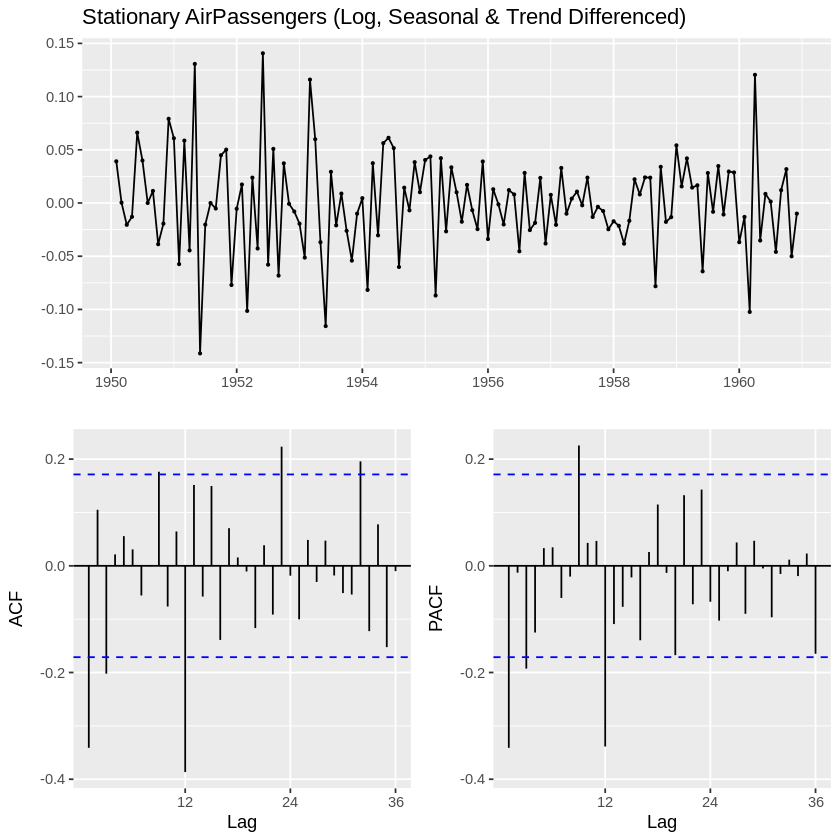

In [11]:
library(forecast)

# 1. Log transform to stabilize variance
# 2. diff(..., lag=12) to remove seasonality
# 3. diff(...) to remove the linear trend
stationary_data <- diff(diff(log(AirPassengers), lag=12))

# Plot the new stationary series along with its ACF and PACF
ggtsdisplay(stationary_data, main = "Stationary AirPassengers (Log, Seasonal & Trend Differenced)")


DO ADF TEST

CHECK ADF RESULT

In [12]:
# Install and load the required package
install.packages("tseries")
library(tseries)

# Perform the ADF test on the raw data
adf_result <- adf.test(AirPassengers)
print(adf_result)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘xts’, ‘TTR’, ‘quadprog’, ‘quantmod’


Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 

Warning message in adf.test(AirPassengers):
“p-value smaller than printed p-value”



	Augmented Dickey-Fuller Test

data:  AirPassengers
Dickey-Fuller = -7.3186, Lag order = 5, p-value = 0.01
alternative hypothesis: stationary



ADF WITH LAG 12

In [13]:
# Test the stationary version we created earlier
stationary_data <- diff(diff(log(AirPassengers), lag=12))
adf.test(stationary_data)


Warning message in adf.test(stationary_data):
“p-value smaller than printed p-value”



	Augmented Dickey-Fuller Test

data:  stationary_data
Dickey-Fuller = -5.1993, Lag order = 5, p-value = 0.01
alternative hypothesis: stationary


KPSS TEST

In [14]:
library(tseries)

# Test the raw data
kpss_raw <- kpss.test(AirPassengers)
print(kpss_raw)

# Test the differenced (stationary) data
stationary_data <- diff(diff(log(AirPassengers), lag=12))
kpss_stationary <- kpss.test(na.omit(stationary_data))
print(kpss_stationary)


Warning message in kpss.test(AirPassengers):
“p-value smaller than printed p-value”



	KPSS Test for Level Stationarity

data:  AirPassengers
KPSS Level = 2.7395, Truncation lag parameter = 4, p-value = 0.01



Warning message in kpss.test(na.omit(stationary_data)):
“p-value greater than printed p-value”



	KPSS Test for Level Stationarity

data:  na.omit(stationary_data)
KPSS Level = 0.084365, Truncation lag parameter = 4, p-value = 0.1



CHECK STATIONARITY ALSO PATTERN ACF AND PACF

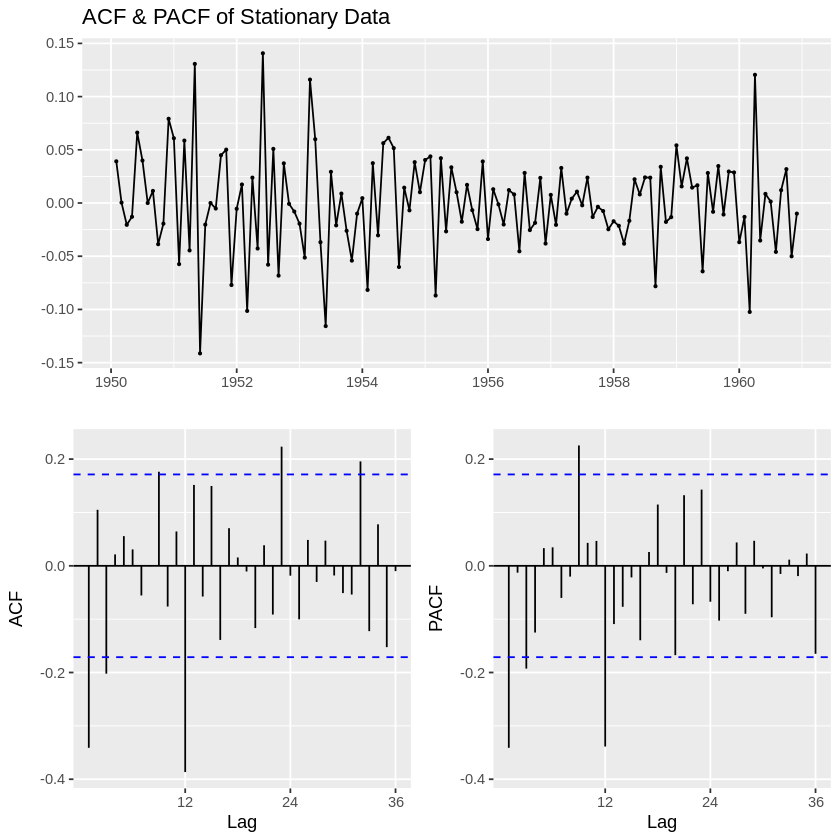

In [29]:
library(forecast)

# 1. Prepare stationary data (Log + Seasonal Difference + Trend Difference)
stationary_data <- diff(diff(log(AirPassengers), lag = 12))

# 2. Plot ACF and PACF side-by-side
# We omit NAs caused by differencing
ggtsdisplay(na.omit(stationary_data), main = "ACF & PACF of Stationary Data")


AUTO ARIMA

Series: log(AirPassengers) 
ARIMA(0,1,1)(0,1,1)[12] 

Coefficients:
          ma1     sma1
      -0.4018  -0.5569
s.e.   0.0896   0.0731

sigma^2 = 0.001371:  log likelihood = 244.7
AIC=-483.4   AICc=-483.21   BIC=-474.77

Training set error measures:
                       ME       RMSE        MAE        MPE      MAPE      MASE
Training set 0.0005730622 0.03504883 0.02626034 0.01098898 0.4752815 0.2169522
                   ACF1
Training set 0.01443892

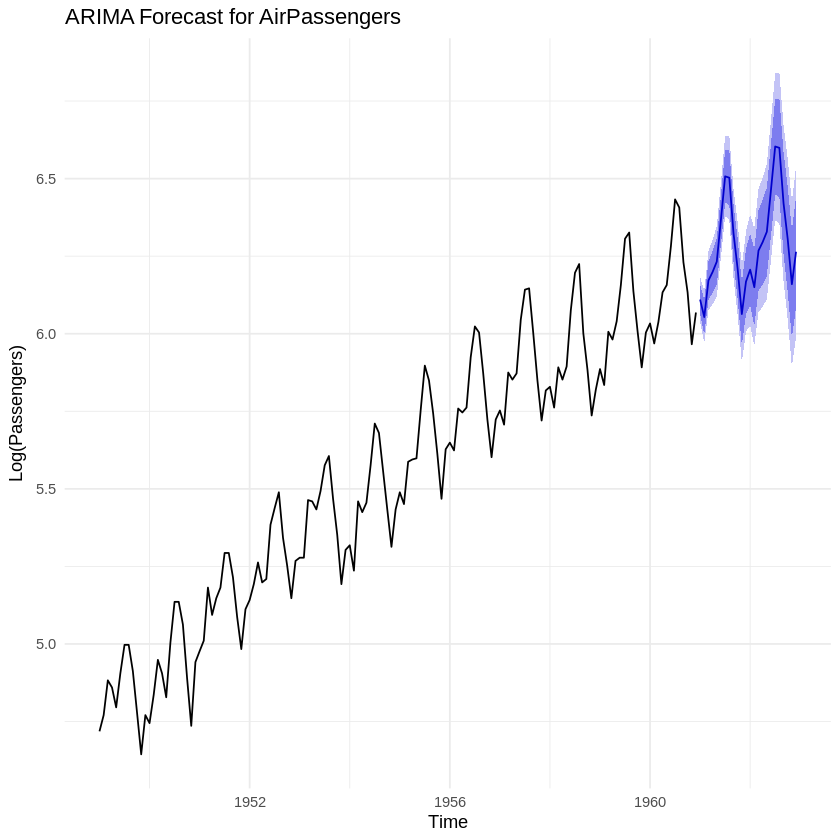

In [15]:
library(forecast)

# 1. Fit the best model automatically
# We use log(AirPassengers) because the variance increases over time
fit <- auto.arima(log(AirPassengers))

# 2. View the model summary (shows chosen p, d, q and seasonal P, D, Q)
summary(fit)

# 3. Forecast the next 2 years (24 months)
future_forecast <- forecast(fit, h = 24)

# 4. Plot the forecast
autoplot(future_forecast) +
  labs(title = "ARIMA Forecast for AirPassengers", y = "Log(Passengers)") +
  theme_minimal()


MANUAL ARIMA, SARIMA


	Ljung-Box test

data:  Residuals from ARIMA(0,1,1)(0,1,1)[12]
Q* = 26.446, df = 22, p-value = 0.233

Model df: 2.   Total lags used: 24



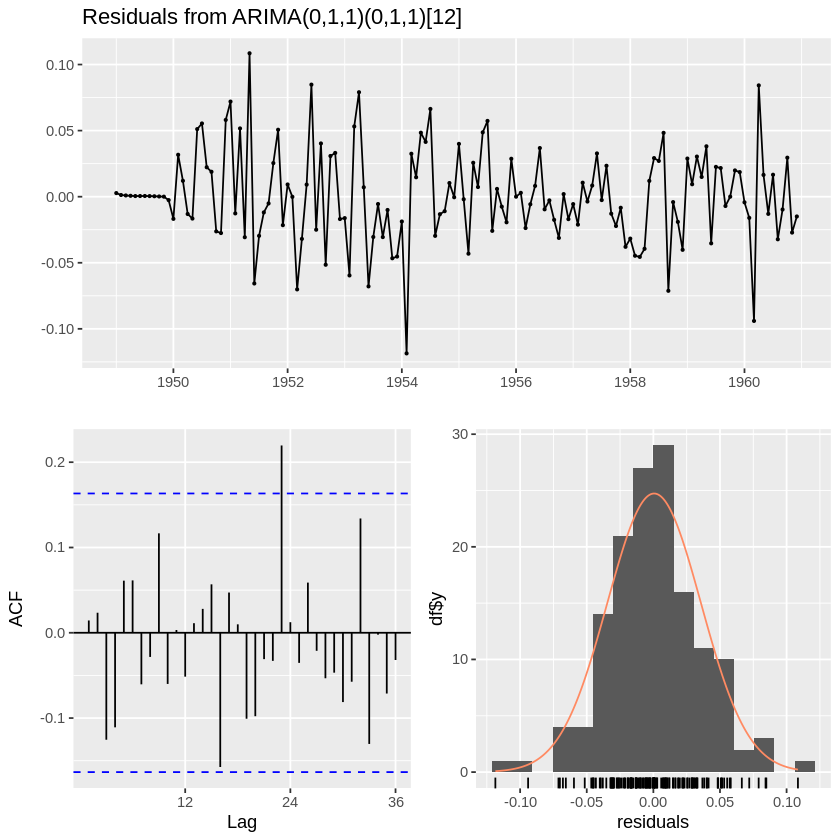

In [16]:
library(forecast)

# Define a specific model: ARIMA(0,1,1) with Seasonal(0,1,1)
# This is a common "Airline Model" for this dataset
manual_fit <- Arima(log(AirPassengers),
                    order = c(0, 1, 1),
                    seasonal = c(0, 1, 1))

# Check the residuals to ensure they look like white noise (random)
checkresiduals(manual_fit)


FORECAST NEXT 12 MONTH

Warning message in plot.window(xlim, ylim, log, ...):
“"lambda" is not a graphical parameter”
Warning message in title(main = main, xlab = xlab, ylab = ylab, ...):
“"lambda" is not a graphical parameter”
Warning message in axis(1, ...):
“"lambda" is not a graphical parameter”
Warning message in axis(2, ...):
“"lambda" is not a graphical parameter”
Warning message in box(...):
“"lambda" is not a graphical parameter”


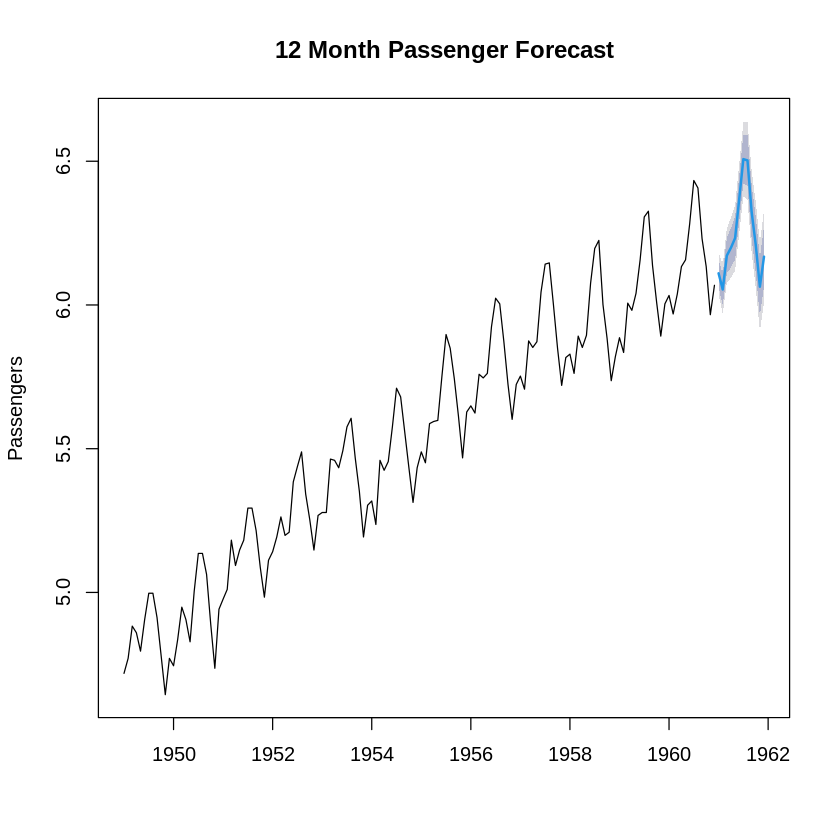

In [17]:
# Forecast for 12 months
fcast <- forecast(manual_fit, h = 12)

# Convert log values back to original scale for readability
# Use exp() because we took the log() earlier
plot(fcast, main = "12 Month Passenger Forecast", ylab = "Passengers", lambda = 0)


TRAIN VS TEST

In [18]:
library(forecast)

# Create training set (up to end of 1959)
train_data <- window(AirPassengers, end = c(1959, 12))

# Create test set (the year 1960)
test_data <- window(AirPassengers, start = c(1960, 1))


TRAIN VS TEST 12 MONTH AHEAD

FIT MODEL

In [19]:
# Fit model on training data
fit_train <- auto.arima(log(train_data))

# Forecast 12 months ahead
fcast_test <- forecast(fit_train, h = 12)


CHECK ACCURACY EVALUATION METRICS

,ME,RMSE,MAE,MPE,MAPE,ACF1,Theil's U
Test set,-12.16183,18.59359,13.26065,-2.666116,2.904473,-0.3013934,0.4094513


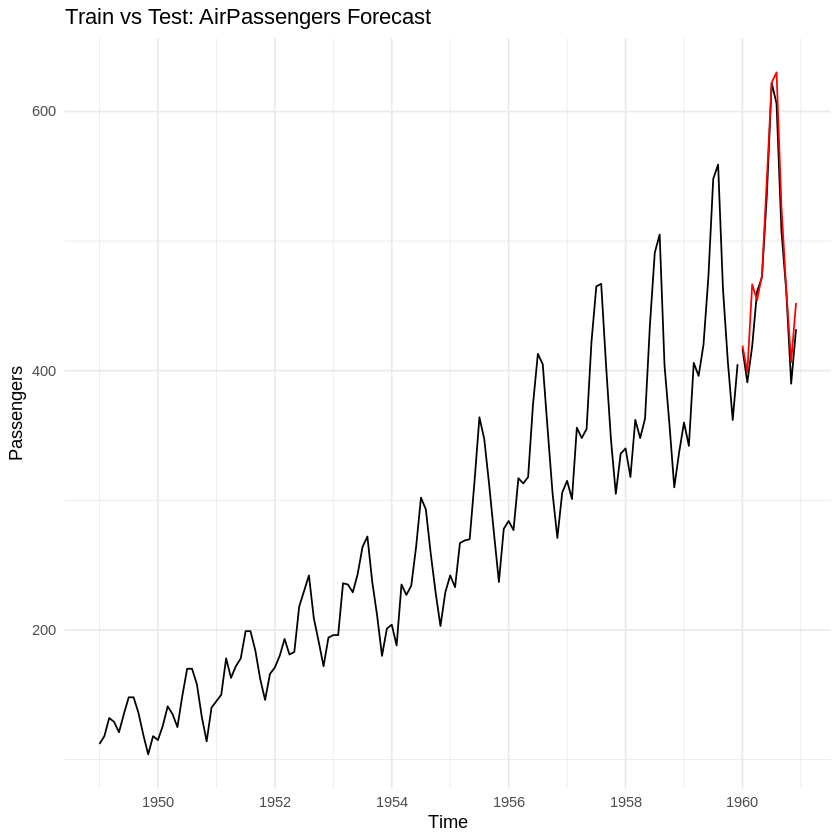

In [20]:
# Calculate error metrics (compare forecast to actual 1960 data)
# We use exp() to convert the log-forecast back to original passenger numbers
accuracy(exp(fcast_test$mean), test_data)

# Plot the comparison
autoplot(train_data) +
  autolayer(test_data, series = "Actual 1960 Data", color = "black") +
  autolayer(exp(fcast_test$mean), series = "Model Prediction", color = "red") +
  labs(title = "Train vs Test: AirPassengers Forecast", y = "Passengers") +
  theme_minimal()


SMOOTHING

In [23]:
# Convert the built-in AirPassengers (ts object) to a Prophet-ready data frame
df <- data.frame(
  ds = seq.Date(from = as.Date("1949-01-01"), by = "month", length.out = length(AirPassengers)),
  y = as.numeric(AirPassengers)
)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘shape’, ‘future.apply’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘globals’, ‘listenv’, ‘parallelly’, ‘mvtnorm’, ‘pcaPP’, ‘DEoptimR’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘furrr’, ‘crosstalk’, ‘warp’, ‘RcppRoll’, ‘future’, ‘pyinit’, ‘rrcov’, ‘robustbase’, ‘recipes’, ‘rsample’, ‘plotly’, ‘padr’, ‘slider’, ‘anytime’, ‘tsfeatures’, ‘lazyeval’, ‘PerformanceAnalytics’, ‘RobStatTM’, ‘timetk’


── Attaching core tidyquant packages ─────────────────────── tidyquant 1.0.12 ──
✔ PerformanceAnalytics 2.1.0      ✔ TTR                  0.24.4
✔ quantmod             0.4.28     ✔ xts                  0.14.2
── Conflicts ────────────────────────────────────────── tidyquant_conflicts() ──
✖ zoo::as.Date()                 masks base::as.Date()
✖ zoo::as.Date.numeric()         masks base::as.Date.numeric()
✖ PerformanceAnalytics::legend() masks graphics::legend(

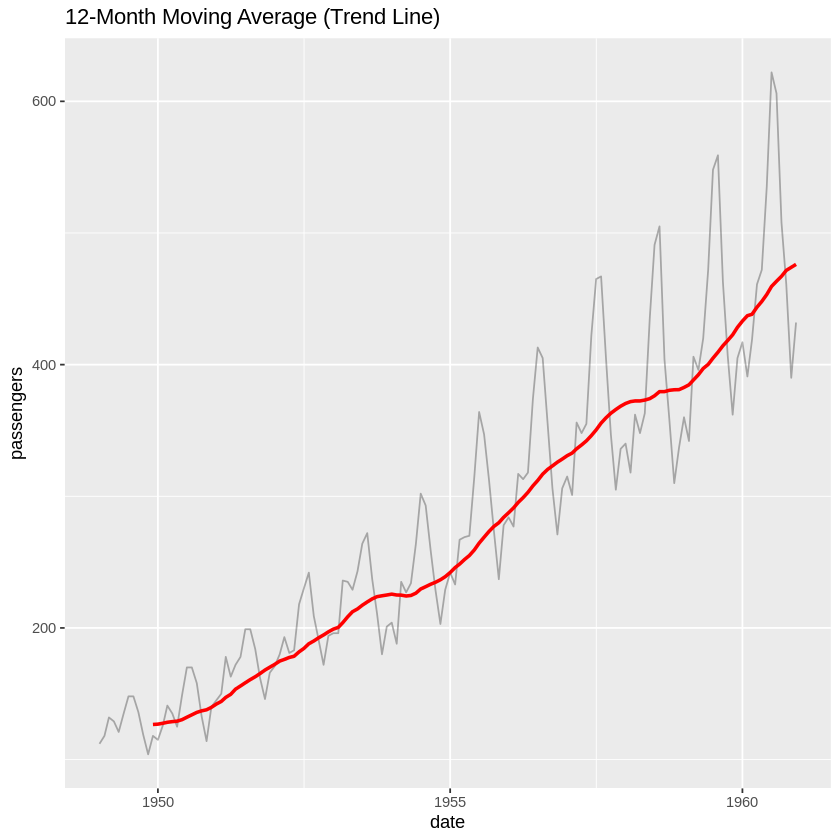

In [24]:
install.packages("tidyquant")
library(tidyquant)
library(ggplot2)

# Convert AirPassengers to a data frame
df <- data.frame(
  date = seq.Date(from = as.Date("1949-01-01"), by = "month", length.out = length(AirPassengers)),
  passengers = as.numeric(AirPassengers)
)

# Calculate a 12-month moving average
ggplot(df, aes(x = date, y = passengers)) +
  geom_line(alpha = 0.3) + # Original data (faded)
  geom_ma(ma_fun = SMA, n = 12, color = "red", linetype = "solid", size = 1) +
  labs(title = "12-Month Moving Average (Trend Line)")


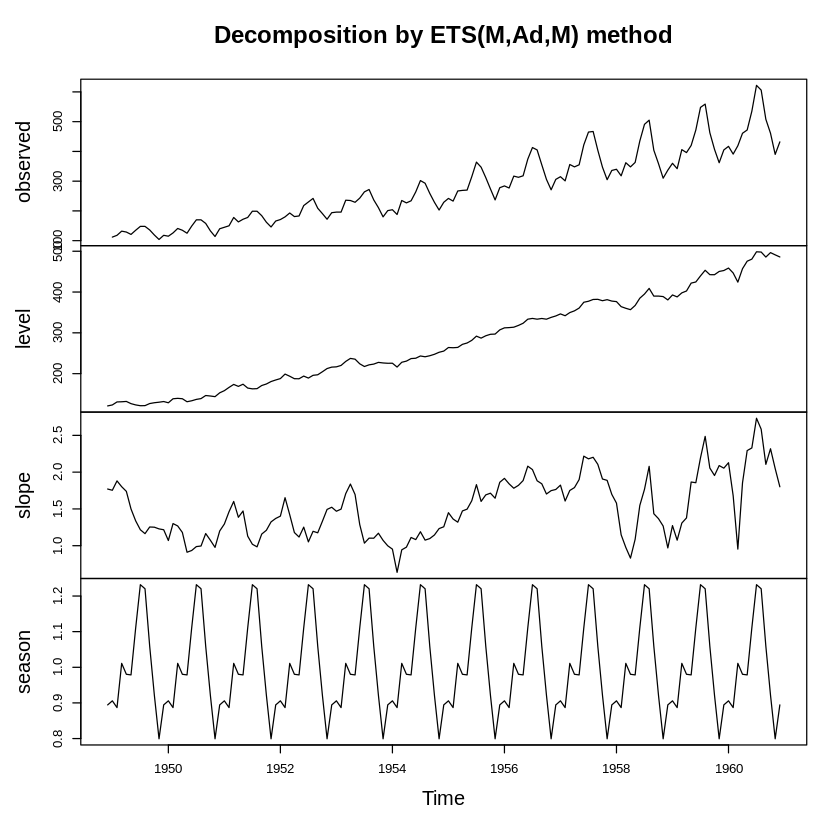

In [25]:
library(forecast)

# Fit an ETS model (Error, Trend, Seasonal)
# 'ZZZ' tells R to choose the best type automatically
fit_ets <- ets(AirPassengers, model = "ZZZ")

# Plot the smoothed components
plot(fit_ets)


`geom_smooth()` using formula = 'y ~ x'


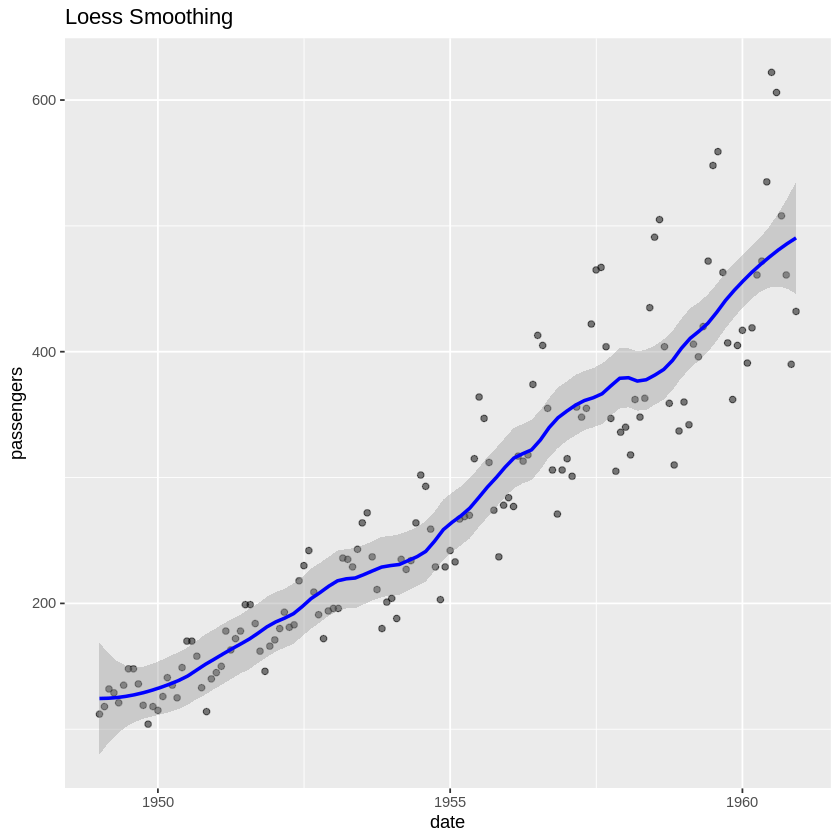

In [26]:
ggplot(df, aes(x = date, y = passengers)) +
  geom_point(alpha = 0.5) +
  geom_smooth(method = "loess", span = 0.3, color = "blue") +
  labs(title = "Loess Smoothing")


HOLT WINTER

Holt-Winters exponential smoothing with trend and multiplicative seasonal component.

Call:
HoltWinters(x = AirPassengers, seasonal = "multiplicative")

Smoothing parameters:
 alpha: 0.2755925
 beta : 0.03269295
 gamma: 0.8707292

Coefficients:
           [,1]
a   469.3232206
b     3.0215391
s1    0.9464611
s2    0.8829239
s3    0.9717369
s4    1.0304825
s5    1.0476884
s6    1.1805272
s7    1.3590778
s8    1.3331706
s9    1.1083381
s10   0.9868813
s11   0.8361333
s12   0.9209877

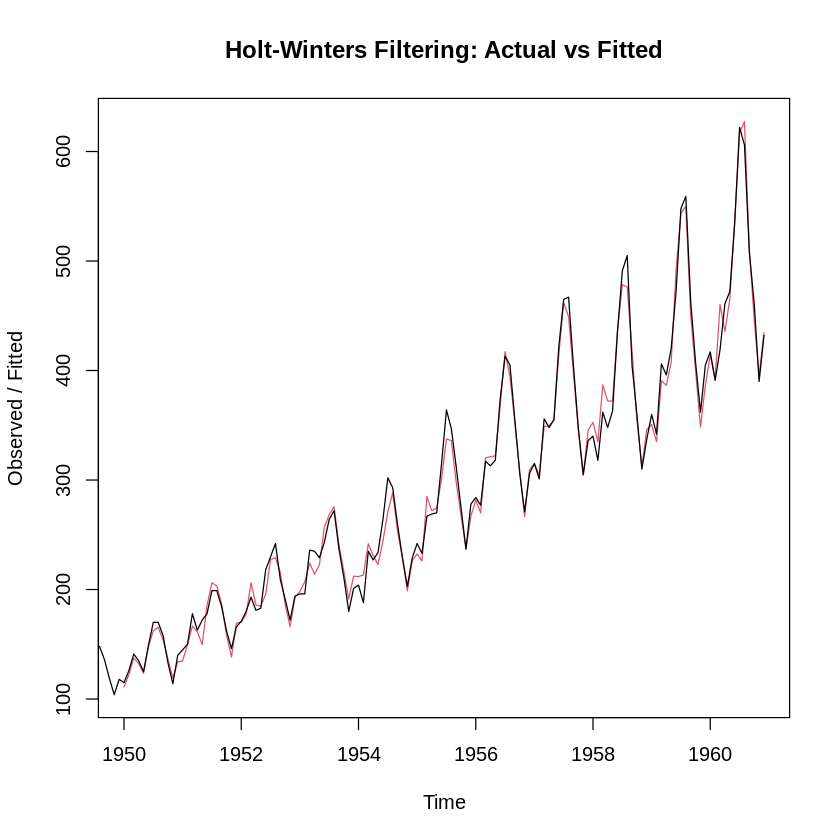

In [27]:
# Fit the Holt-Winters model
# 'multiplicative' is used because the seasonal swings increase with the trend
hw_model <- HoltWinters(AirPassengers, seasonal = "multiplicative")

# View the smoothing parameters (alpha, beta, gamma)
hw_model

# Plot the original data (black) vs the fitted values (red)
plot(hw_model, main = "Holt-Winters Filtering: Actual vs Fitted")


PLOT NEXT 3 YEAR

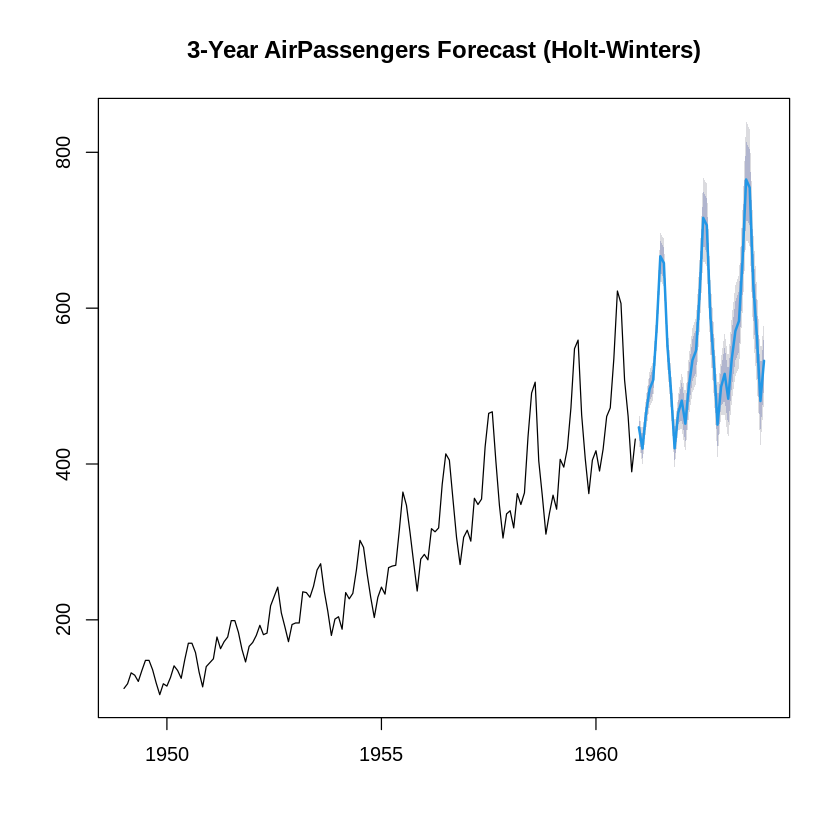

In [28]:
library(forecast)

# Forecast for the next 3 years (36 months)
hw_forecast <- forecast(hw_model, h = 36)

# Plot the forecast with confidence intervals
plot(hw_forecast, main = "3-Year AirPassengers Forecast (Holt-Winters)")


WHITE NOISE

In [31]:
# Test the residuals of your previous ARIMA model
# fit$residuals is the data being tested
Box.test(fit$residuals, lag = 12, type = "Ljung-Box")



	Box-Ljung test

data:  fit$residuals
X-squared = 9.2333, df = 12, p-value = 0.6829


CHECK RESIDUALS

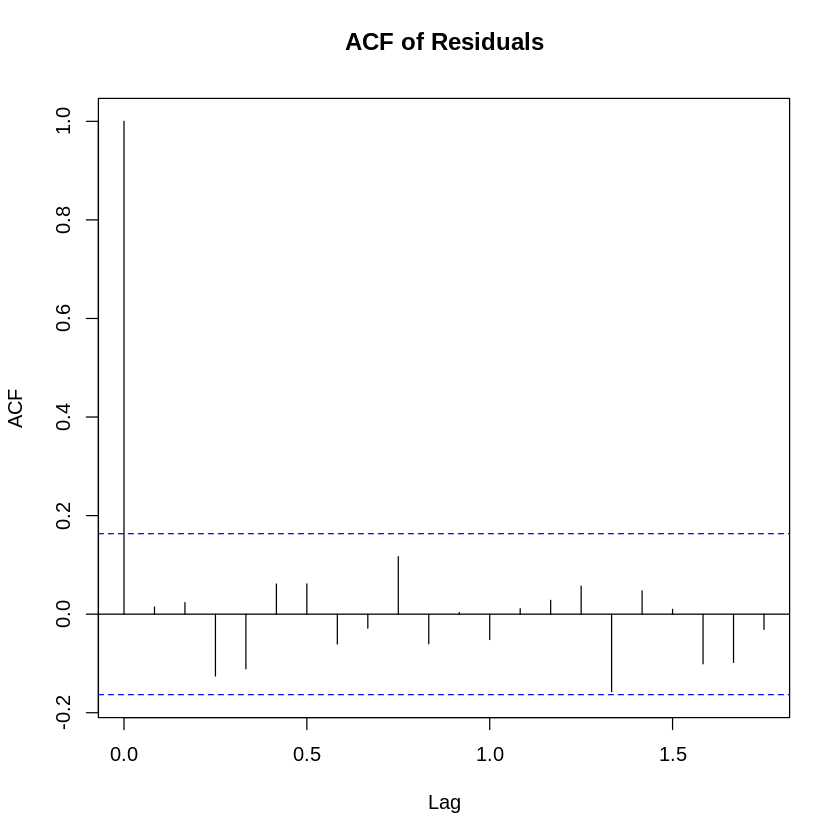

In [32]:
acf(fit$residuals, main = "ACF of Residuals")


CHECK RESULTS


	Ljung-Box test

data:  Residuals from ARIMA(0,1,1)(0,1,1)[12]
Q* = 26.446, df = 22, p-value = 0.233

Model df: 2.   Total lags used: 24



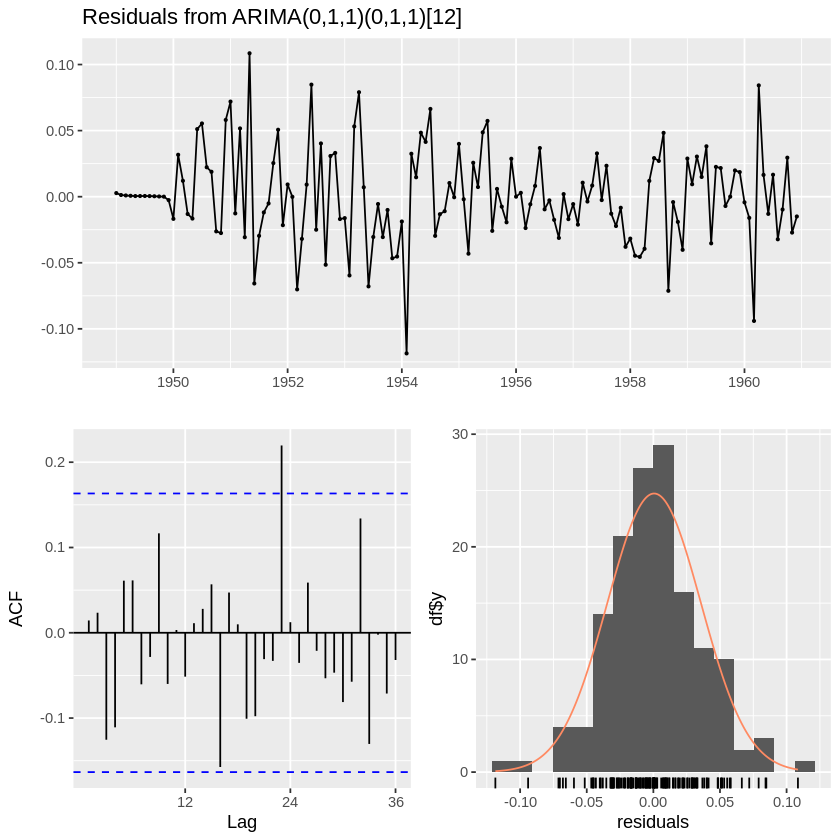

In [33]:
library(forecast)
checkresiduals(fit)


SHEWART CONTROL CHART

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Package 'qcc' version 2.7

Type 'citation("qcc")' for citing this R package in publications.



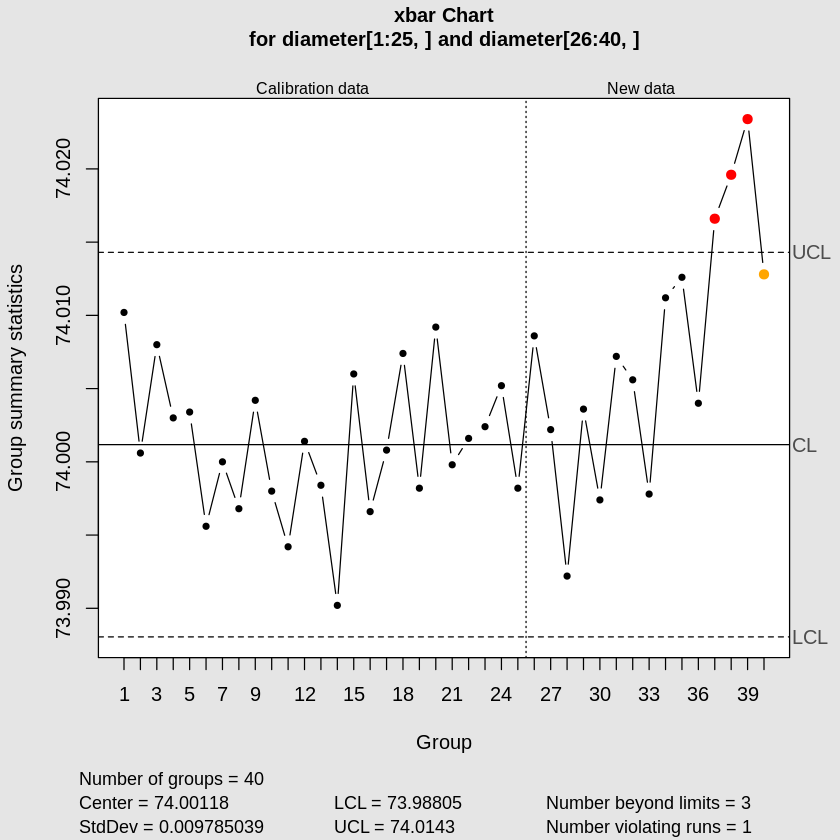

In [30]:
# Install and load the package
install.packages("qcc")
library(qcc)

# Example: Using the built-in 'pistonrings' dataset
data(pistonrings)
diameter <- with(pistonrings, qcc.groups(diameter, sample))

# Create an X-bar chart (monitors the mean)
obj <- qcc(diameter[1:25,], type = "xbar", newdata = diameter[26:40,])
